<a href="https://colab.research.google.com/github/alexlau818/github-pages-with-jekyll/blob/main/csdi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas

In [ ]:
pip install geopandas

In [ ]:
pip install contextily

In [ ]:
import requests
import pandas as pd
import geopandas as gpd
import contextily as cx
import matplotlib.pyplot as plt
import os
from datetime import datetime as dt
from datetime import timedelta as td
import xml.etree.ElementTree as ET
import json
from IPython.display import display,HTML,Image,JSON
import cgi

def validate_json(text):
  try:
    temp=json.loads(text)
  except:
    print('json error')

def get_resp(link):
  try:
    resp=requests.get(link,headers=headers)
  except:
    print(f'***error***')
  return resp

def checklink(link,type):
  count='-'
  #print(headers)
  display(HTML(f'<a href="{link}">{type}</a>'))
  if type=='ARCGIS':
    #link=link.replace('?f=json','/0/query?where=1%3d1&returncountonly=true&f=json')
    resp=get_resp(link)
    if resp.status_code==200:
      result=resp.json()
      for lyr in result['layers']:
        lyrid=lyr['id']
        lyrnm=lyr['name']
        if 'geometryType' in lyr:
          lyrgeom=lyr['geometryType']
        else:
          lyrgeom='-'
        link1=link.replace('?f=json',f'/{lyrid}/query?where=1%3d1&returncountonly=true&f=json')
        #print(link1)
        resp1=get_resp(link1)
        if resp1.status_code==200:
          result1=resp1.json()
          if 'count' in resp1.text:
            count=result1['count']
          else:
            count=f'***error {resp1.text}'
        else:
          count=f'***error {resp1.status_code}***'
        display(HTML(f'<a href="{link1}">{lyrnm}</a>'))
        #display(count)
        #print(f'layer: {lyrid}-{lyrnm}')
        print(f'geom: {lyrgeom}')
        print(f'count: {count}')
        print(f'time: {resp1.elapsed.total_seconds()}s')
    else:
      print(f'***error {resp.status_code}***')
  elif type in ['WFS','WMS']:
    resp=get_resp(link)
    print(f'status: {resp.status_code}')
    print(f'time: {resp.elapsed.total_seconds()}s')
    #display(resp.status_code)
  elif type in ['FGDB','GML','GEOPACKAGE','SHP','GEOJSON','KML','CSV','GEOTIFF','SDS_VIEW','SDS_XML','SDS_JSON','FILE_API_GEOJSON']:
    resp=requests.head(link,headers=headers)
    if resp.status_code==200:
      value,params=cgi.parse_header(resp.headers['Content-Disposition'])
      fname=params.get('filename')
      fsize=resp.headers['content-length']
      print(f'{fname}')
      print(f'size : {fsize} bytes')
      print(f'time: {resp.elapsed.total_seconds()}s')
      #if type=='FILE_API_GEOJSON':
        #gdfplt(link)
      #display(fname,fsize)
    else:
      print(f'status: {resp.status_code}')

def gdfplt(link):
  gdf=gpd.read_file(link)
  gdf_3857=gdf.to_crs(epsg=3857)
  fig, ax=plt.subplots(figsize=(10,10))
  gdf_3857.plot(ax=ax,alpha=0.5,color='red')
  cx.add_basemap(ax)
  ax.set_axis_off()
  plt.show()
  #display(gdf.head(5))

def correctdate(datestring):
  if len(datestring)==4:
    datestring=datestring+'-01-01'
  elif len(datestring)==7:
    datestring=datestring+'-01'
  elif len(datestring)>10:
    datestring=datestring[0:10]
  return datestring

def getxmllink(xmlstr,index,chk=True):
  ns={'gmd':'http://www.isotc211.org/2005/gmd','gco':'http://www.isotc211.org/2005/gco'}
  root=ET.fromstring(xmlstr)
  creatDate='-'
  revDate='-'
  pubDate='-'
  metDate='-'
  dstamp=root.find('gmd:dateStamp',ns)
  try:
    metDate=root.find('gmd:dateStamp',ns).find('gco:Date',ns).text
  except:
    metDate=root.find('gmd:dateStamp',ns).find('gco:DateTime',ns).text
  metDate=correctdate(metDate)
  df.at[index,'metadata_date']=metDate
  mdid=root.find('gmd:identificationInfo',ns).find('gmd:MD_DataIdentification',ns)
  md_main=mdid.find('gmd:resourceMaintenance',ns).find('gmd:MD_MaintenanceInformation',ns)
  freqCode=md_main.find('gmd:maintenanceAndUpdateFrequency',ns).find('gmd:MD_MaintenanceFrequencyCode',ns).attrib['codeListValue']
  for text in md_main.find('gmd:maintenanceNote',ns).find('gmd:PT_FreeText',ns).findall('gmd:textGroup',ns):
    locale=text.find('gmd:LocalisedCharacterString',ns).attrib['locale']
    if locale=="#EN":
      freq_en=text.find('gmd:LocalisedCharacterString',ns).text
    if locale=="#ZH":
      freq_zh=text.find('gmd:LocalisedCharacterString',ns).text
    if locale=='#CN':
      freq_cn=text.find('gmd:LocalisedCharacterString',ns).text
  df.at[index,'freq']=freq_en
  cit=mdid.find('gmd:citation',ns).find('gmd:CI_Citation',ns)
  md_main=mdid.find('gmd:resourceMaintenance',ns).find('gmd:MD_MaintenanceInformation',ns)
  for mdate in cit.findall('gmd:date',ns):
    mdateType=mdate.find('gmd:CI_Date',ns).find('gmd:dateType',ns).find('gmd:CI_DateTypeCode',ns).attrib['codeListValue']
    if mdateType=='creation':
      creatDate=mdate.find('gmd:CI_Date',ns).find('gmd:date',ns).find('gco:Date',ns).text
      creatDate=correctdate(creatDate)
      df.at[index,'creation_date']=creatDate
    elif mdateType=='revision':
      revDate=mdate.find('gmd:CI_Date',ns).find('gmd:date',ns).find('gco:Date',ns).text
      revDate=correctdate(revDate)
      df.at[index,'revision_date']=revDate
    elif mdateType=='publication':
      pubDate=mdate.find('gmd:CI_Date',ns).find('gmd:date',ns).find('gco:Date',ns).text
      pubDate=correctdate(pubDate)
      df.at[index,'publication_date']=pubDate
    else:
      print('*** no date type ***')
  mdist=root.find('gmd:distributionInfo',ns).find('gmd:MD_Distribution',ns)
  for transOpt in mdist.findall('gmd:transferOptions',ns):
    link='-'
    type='-'
    if transOpt.find('gmd:MD_DigitalTransferOptions',ns).find('gmd:onLine',ns) is not None:
      online=transOpt.find('gmd:MD_DigitalTransferOptions',ns).find('gmd:onLine',ns)
      if online.find('gmd:CI_OnlineResource',ns) is not None:
        onlineres=online.find('gmd:CI_OnlineResource',ns)
        if onlineres.find('gmd:linkage',ns) is not None:
          link=onlineres.find('gmd:linkage',ns).find('gmd:URL',ns).text
        if onlineres.find('gmd:applicationProfile',ns) is not None:
          type=onlineres.find('gmd:applicationProfile',ns).find('gco:CharacterString',ns).text
    if 'download' in link:
      link=link.replace('portal','static')
    if 'view' in link:
      link=link.replace('portal','static')
    if 'FeatureServer' in link:
      link=link+'?f=json'
    if 'MapServer' in link:
      if 'WFSServer' in link:
        link=link
      elif 'WMSServer' in link:
        link=link
      else:
        link=link+'?f=json'
    #display(HTML(f'<a href="{link}">{type}</a>'))
    #print(link)
    if chk:
      checklink(link,type)
    df.at[index,type]=f'<a href="{link}">Y</a>'
    row={'id':id,'type':type,'link':link}
    linkres.append(row)
  return

def getopensearch(site,n):
  headers={'user-agent':'CSWCheckBot','x-csdi-site':site}
  url=f'https://portal.csdi.gov.hk/geoportal/opensearch?sort=modified:desc&num={n}&f=json'
  resp=requests.get(url,headers=headers)
  return resp

def saveresp(resp,site):
  d_str=dt.now().strftime('%Y%m%d')
  path='/content/drive/MyDrive/CSDI/json'
  file_name=f'{site}_{d_str}.json'
  file_path=os.path.join(path,file_name)
  with open(file_path,'wb') as fp:
    fp.write(resp.content)

def readjson(site):
  d_str=dt.now().strftime('%Y%m%d')
  path='/content/drive/MyDrive/CSDI/json'
  file_name=f'{site}_{d_str}.json'
  file_path=os.path.join(path,file_name)
  with open(file_path,'r',encoding='utf-8') as rp:
    result=json.load(rp)
  df=pd.json_normalize(result['results'])
  df['updated']=df['updated'].apply(lambda x:dt.strptime(x,'%Y-%m-%dT%H:%M:%S.%fZ' if len(x)==24 else '%Y-%m-%dT%H:%M:%SZ'))+td(hours=8)
  return df

def getlink(links, site):
  for link in links:
    profile='-'
    if 'server/rest/services' in link:
      if 'MapServer' in link:
        profile='MAP'
      else:
        profile='FS'
      link=link+'?f=json'
    elif 'WFS' in link:
      profile='WFS'
    elif 'WMS' in link:
      profile='WMS'
    elif 'download' in link:
      profile='DL'
      link=link.replace('portal','static')
      checksdsjson(link,site)
    elif 'view' in link:
      profile='VIEW'
      link=link.replace('portal','static')
      checksdsjson(link,site)
    elif 'file-api' in link:
      profile='FAPI'
      link=link.replace('portal','static')
    elif 'archived' in link:
      profile='ARCH'
    elif 'dataquery' in link:
      profile='DQS'
    display(HTML(f'<a href="{link}">{profile}</a>'))

def checksdsjson(link,site):
  headers={'user-agent':'CSWCheckBot','x-csdi-site':site}
  resp=requests.head(link,headers=headers)
  print(f'-site: {site}')
  #print(f'-link: {link}')
  print(f'-status: {resp.status_code}')
  if resp.status_code==200:
    #print(resp.headers.keys())
    if 'Content-Disposition' in resp.headers:
      value, params=cgi.parse_header(resp.headers['Content-Disposition'])
      filename=params.get('filename')
      display(HTML(f'<a href="{link}">{filename}</a>'))
    print(f'-size: {resp.headers["content-length"]}')
  else:
    print('-response error')

def readdate(xmltext):
  ns={'gmd':'http://www.isotc211.org/2005/gmd','gco':'http://www.isotc211.org/2005/gco'}
  root=ET.fromstring(xmltext)
  creatDate='-'
  revDate='-'
  pubDate='-'
  metDate='-'
  dstamp=root.find('gmd:dateStamp',ns)
  try:
    metDate=root.find('gmd:dateStamp',ns).find('gco:Date',ns).text
  except:
    metDate=root.find('gmd:dateStamp',ns).find('gco:DateTime',ns).text
  mdid=root.find('gmd:identificationInfo',ns).find('gmd:MD_DataIdentification',ns)
  cit=mdid.find('gmd:citation',ns).find('gmd:CI_Citation',ns)
  for mdate in cit.findall('gmd:date',ns):
    mdateType=mdate.find('gmd:CI_Date',ns).find('gmd:dateType',ns).find('gmd:CI_DateTypeCode',ns).attrib['codeListValue']
    if mdateType=='creation':
      creatDate=mdate.find('gmd:CI_Date',ns).find('gmd:date',ns).find('gco:Date',ns).text
    elif mdateType=='revision':
      revDate=mdate.find('gmd:CI_Date',ns).find('gmd:date',ns).find('gco:Date',ns).text
    elif mdateType=='publication':
      pubDate=mdate.find('gmd:CI_Date',ns).find('gmd:date',ns).find('gco:Date',ns).text
    else:
      print('*** no date type ***')
  return creatDate,revDate,pubDate,metDate

def checkdat(df,st,en):
  linkres=[]
  for index, row in df.loc[st:en].iterrows():
    id=row['id']
    title=row['title']
    upd=row['updated']
    xmltext=row['_source.sys_xml_clob']
    creatDt, revDt, pubDt, metDate=readdate(xmltext)
    display(HTML('<hr>'))
    display(index,id,upd)
    display(creatDt, revDt, pubDt, metDate)
    display(HTML(f'<a href="https://portal.csdi.gov.hk/geoportal/?lang=en&datasetId={id}">{title}</a>'))
    #print('***error preview***')
    df.at[index,'title']=f'<a href="https://portal.csdi.gov.hk/geoportal/?lang=en&datasetId={id}">{title}</a>'
    try:
      #resp=requests.get(row['_source.url_thumbnail_s'])
      display(Image(requests.get(row['_source.thumbnail_s'],headers=headers).content))
    except:
      print('***preview error***')
    getxmllink(xmltext,index)

def readxml(xmltext):
  ns={'gmd':'http://www.isotc211.org/2005/gmd','gco':'http://www.isotc211.org/2005/gco','gts':'http://www.isotc211.org/2005/gts'}
  root=ET.fromstring(xmltext)
  if root.find('gmd:fileIdentifier',ns) is not None:
    fileid=root.find('gmd:fileIdentifier',ns).find('gco:CharacterString',ns).text
  else:
    fileid='-'
  if root.find('gmd:hierarchyLevel',ns) is not None:
    hierarchyLvl=root.find('gmd:hierarchyLevel',ns).find('gmd:MD_ScopeCode',ns).attrib['codeListValue']
  else:
    hierarchyLvl='-'
  md_identification=root.find('gmd:identificationInfo',ns).find('gmd:MD_DataIdentification',ns)
  ci_cita=md_identification.find('gmd:citation',ns).find('gmd:CI_Citation',ns)
  #if root.find('gmd:identificationInfo',ns).find('gmd:MD_DataIdentification',ns).find('gmd:pointOfContact',ns):
    #ci_resp=root.find('gmd:identificationInfo',ns).find('gmd:MD_DataIdentification',ns).find('gmd:pointOfContact',ns).find('gmd:CI_ResponsibleParty',ns)
  resp_org_en='-'
  resp_org_zh='-'
  resp_org_cn='-'
  resp_pos_en='-'
  resp_pos_zh='-'
  resp_pos_cn='-'
  title_en='-'
  title_zh='-'
  title_cn='-'
  abstract_en='-'
  abstract_zh='-'
  abstract_cn='-'
  creatDate='-'
  revDate='-'
  pubDate='-'
  metDate='-'
  freqCode='-'
  freq_en='-'
  freq_zh='-'
  freq_cn='-'
  phone='-'
  fax='-'
  email='-'
  cat_en='-'
  cat_zh='-'
  cat_cn='-'
  theme_en='-'
  theme_zh='-'
  theme_cn='-'
  fsdt_en='-'
  fsdt_zh='-'
  fsdt_cn='-'
  key_en='-'
  key_zh='-'
  key_cn='-'
  keylist=[]
  catlist=[]
  try:
    metDate=root.find('gmd:dateStamp',ns).find('gco:Date',ns).text
  except:
    metDate=root.find('gmd:dateStamp',ns).find('gco:DateTime',ns).text
  for text in ci_cita.find('gmd:title',ns).find('gmd:PT_FreeText',ns).findall('gmd:textGroup',ns):
    locale=text.find('gmd:LocalisedCharacterString',ns).attrib['locale']
    if locale=="#EN":
      title_en=text.find('gmd:LocalisedCharacterString',ns).text
    if locale=="#ZH":
      title_zh=text.find('gmd:LocalisedCharacterString',ns).text
    if locale=='#CN':
      title_cn=text.find('gmd:LocalisedCharacterString',ns).text
  for mdate in ci_cita.findall('gmd:date',ns):
    mdateType=mdate.find('gmd:CI_Date',ns).find('gmd:dateType',ns).find('gmd:CI_DateTypeCode',ns).attrib['codeListValue']
    if mdateType=='creation':
      creatDate=mdate.find('gmd:CI_Date',ns).find('gmd:date',ns).find('gco:Date',ns).text
    elif mdateType=='revision':
      revDate=mdate.find('gmd:CI_Date',ns).find('gmd:date',ns).find('gco:Date',ns).text
    elif mdateType=='publication':
      pubDate=mdate.find('gmd:CI_Date',ns).find('gmd:date',ns).find('gco:Date',ns).text
    else:
      print('*** no date type ***')
  for text in md_identification.find('gmd:abstract',ns).find('gmd:PT_FreeText',ns).findall('gmd:textGroup',ns):
    locale=text.find('gmd:LocalisedCharacterString',ns).attrib['locale']
    if locale=="#EN":
      abstract_en=text.find('gmd:LocalisedCharacterString',ns).text
    if locale=="#ZH":
      abstract_zh=text.find('gmd:LocalisedCharacterString',ns).text
    if locale=='#CN':
      abstract_cn=text.find('gmd:LocalisedCharacterString',ns).text
  md_main=md_identification.find('gmd:resourceMaintenance',ns).find('gmd:MD_MaintenanceInformation',ns)
  freqCode=md_main.find('gmd:maintenanceAndUpdateFrequency',ns).find('gmd:MD_MaintenanceFrequencyCode',ns).attrib['codeListValue']
  for text in md_main.find('gmd:maintenanceNote',ns).find('gmd:PT_FreeText',ns).findall('gmd:textGroup',ns):
    locale=text.find('gmd:LocalisedCharacterString',ns).attrib['locale']
    if locale=="#EN":
      freq_en=text.find('gmd:LocalisedCharacterString',ns).text
    if locale=="#ZH":
      freq_zh=text.find('gmd:LocalisedCharacterString',ns).text
    if locale=='#CN':
      freq_cn=text.find('gmd:LocalisedCharacterString',ns).text
  #md_key=md_identification.find('gmd:descriptiveKeywords',ns).find('gmd:MD_Keywords',ns)
  for d_keyword in md_identification.findall('gmd:descriptiveKeywords',ns):
    md_key=d_keyword.find('gmd:MD_Keywords',ns)
    if md_key.find('gmd:thesaurusName',ns) is not None:
      t_title=md_key.find('gmd:thesaurusName',ns).find('gmd:CI_Citation',ns).find('gmd:title',ns).find('gco:CharacterString',ns).text
      print(f'Thesaurus: {t_title}')
    if 'Class' in t_title:
      for keyword in md_key.findall('gmd:keyword',ns):
        theme=keyword.find('gco:CharacterString',ns).text
        print(theme)
        if 'Sharable' in theme:
          theme_en=theme
        elif 'Framework' in theme:
          for text in keyword.find('gmd:PT_FreeText',ns).findall('gmd:textGroup',ns):
            locale=text.find('gmd:LocalisedCharacterString',ns).attrib['locale']
            if locale=="#EN":
              theme_en=text.find('gmd:LocalisedCharacterString',ns).text
            if locale=="#ZH":
              theme_zh=text.find('gmd:LocalisedCharacterString',ns).text
            if locale=='#CN':
              theme_cn=text.find('gmd:LocalisedCharacterString',ns).text
        elif 'FSDT' in theme:
          for text in keyword.find('gmd:PT_FreeText',ns).findall('gmd:textGroup',ns):
            locale=text.find('gmd:LocalisedCharacterString',ns).attrib['locale']
            if locale=="#EN":
              fsdt_en=text.find('gmd:LocalisedCharacterString',ns).text
            if locale=="#ZH":
              fsdt_zh=text.find('gmd:LocalisedCharacterString',ns).text
            if locale=='#CN':
              fsdt_cn=text.find('gmd:LocalisedCharacterString',ns).text
        else:
          print('*** not a theme ***')
    elif 'category' in t_title:
      #catlist=[]
      if keyword.find('gmd:PT_FreeText',ns):
        for text in keyword.find('gmd:PT_FreeText',ns).findall('gmd:textGroup',ns):
          locale=text.find('gmd:LocalisedCharacterString',ns).attrib['locale']
          if locale=="#EN":
            cat_en=text.find('gmd:LocalisedCharacterString',ns).text
          if locale=="#ZH":
            cat_zh=text.find('gmd:LocalisedCharacterString',ns).text
          if locale=='#CN':
            cat_cn=text.find('gmd:LocalisedCharacterString',ns).text
      else:
        cat_en=theme
      row={'cat_en':cat_en,'cat_zh':cat_zh,'cat_cn':cat_cn}
      catlist.append(row)
    else:
      #keylist=[]
      if keyword.find('gmd:PT_FreeText',ns):
        for text in keyword.find('gmd:PT_FreeText',ns).findall('gmd:textGroup',ns):
          locale=text.find('gmd:LocalisedCharacterString',ns).attrib['locale']
          if locale=="#EN":
            key_en=text.find('gmd:LocalisedCharacterString',ns).text
          if locale=="#ZH":
            key_zh=text.find('gmd:LocalisedCharacterString',ns).text
          if locale=='#CN':
            key_cn=text.find('gmd:LocalisedCharacterString',ns).text
      else:
        key_en=theme
      row={'key_en':key_en,'key_zh':key_zh,'key_cn':key_cn}
      keylist.append(row)

  if root.find('gmd:contact',ns) is not None:
    if root.find('gmd:contact',ns).find('gmd:CI_ResponsibleParty',ns) is not None:
      if root.find('gmd:contact',ns).find('gmd:CI_ResponsibleParty',ns).find('gmd:organisationName',ns) is not None:
        if root.find('gmd:contact',ns).find('gmd:CI_ResponsibleParty',ns).find('gmd:organisationName',ns).find('gmd:PT_FreeText',ns) is not None:
          for text in root.find('gmd:contact',ns).find('gmd:CI_ResponsibleParty',ns).find('gmd:organisationName',ns).find('gmd:PT_FreeText',ns).findall('gmd:textGroup',ns):
            locale=text.find('gmd:LocalisedCharacterString',ns).attrib['locale']
            if locale=="#EN":
              resp_org_en=text.find('gmd:LocalisedCharacterString',ns).text
            elif locale=="#ZH":
              resp_org_zh=text.find('gmd:LocalisedCharacterString',ns).text
            elif locale=="#CN":
              resp_org_cn=text.find('gmd:LocalisedCharacterString',ns).text
            else:
              resp_org_en=root.find('gmd:contact',ns).find('gmd:CI_ResponsibleParty',ns).find('gmd:organisationName',ns).find('gco:CharacterString',ns).text
      if root.find('gmd:contact',ns).find('gmd:CI_ResponsibleParty',ns).find('gmd:positionName',ns) is not None:
        posName=root.find('gmd:contact',ns).find('gmd:CI_ResponsibleParty',ns).find('gmd:positionName',ns)
      else:
        posName=root.find('gmd:identificationInfo',ns).find('gmd:MD_DataIdentification',ns).find('gmd:pointOfContact',ns).find('gmd:CI_ResponsibleParty',ns).find('gmd:positionName',ns)
      if posName.find('gmd:PT_FreeText',ns) is not None:
        for text in posName.find('gmd:PT_FreeText',ns).findall('gmd:textGroup',ns):
          locale=text.find('gmd:LocalisedCharacterString',ns).attrib['locale']
          if locale=="#EN":
            resp_pos_en=text.find('gmd:LocalisedCharacterString',ns).text
          elif locale=="#ZH":
            resp_pos_zh=text.find('gmd:LocalisedCharacterString',ns).text
          elif locale=="#CN":
            resp_pos_cn=text.find('gmd:LocalisedCharacterString',ns).text
          else:
            resp_pos_en=posName.find('gco:CharacterString',ns).text
      if root.find('gmd:contact',ns).find('gmd:CI_ResponsibleParty',ns).find('gmd:contactInfo',ns) is not None:
        ci_contact=root.find('gmd:contact',ns).find('gmd:CI_ResponsibleParty',ns).find('gmd:contactInfo',ns).find('gmd:CI_Contact',ns)
      elif root.find('gmd:identificationInfo',ns).find('gmd:MD_DataIdentification',ns).find('gmd:pointOfContact',ns).find('gmd:CI_ResponsibleParty',ns).find('gmd:contactInfo',ns):
        ci_contact=root.find('gmd:identificationInfo',ns).find('gmd:MD_DataIdentification',ns).find('gmd:pointOfContact',ns).find('gmd:CI_ResponsibleParty',ns).find('gmd:contactInfo',ns).find('gmd:CI_Contact',ns)
      else:
        ci_contact=None
      if ci_contact is not None:
        if ci_contact.find('gmd:phone',ns):
          ci_phone=ci_contact.find('gmd:phone',ns).find('gmd:CI_Telephone',ns)
          if ci_phone.find('gmd:voice',ns):
            phone=ci_phone.find('gmd:voice',ns).find('gco:CharacterString',ns).text
          if ci_phone.find('gmd:fax',ns):
            fax=ci_phone.find('gmd:fax',ns).find('gco:CharacterString',ns).text
        if ci_contact.find('gmd:address',ns):
          ci_address=ci_contact.find('gmd:address',ns).find('gmd:CI_Address',ns)
          if ci_address.find('gmd:electronicMailAddress',ns):
            email=ci_address.find('gmd:electronicMailAddress',ns).find('gco:CharacterString',ns).text
  print('***Title***')
  print(title_en)
  print(title_zh)
  print(title_cn)
  print('***Theme***')
  print(theme_en)
  print(theme_zh)
  print(theme_cn)
  print('***FSDT***')
  print(fsdt_en)
  print(fsdt_zh)
  print(fsdt_cn)
  print('***Category***')
  print(catlist)
  print('***Keyword***')
  if keylist:
    print(keylist)
  print('***Abstract***')
  print(abstract_en)
  print(abstract_zh)
  print(abstract_cn)
  print('***Date***')
  print(f'metadata Date: {metDate}')
  print(f'Creation Date: {creatDate}')
  print(f'Revision Date: {revDate}')
  print(f'Publication Date: {pubDate}')
  print('***Update Frequency***')
  print(f'Freq Code: {freqCode}')
  print(freq_en)
  print(freq_zh)
  print(freq_cn)
  print('***Organization***')
  print(resp_org_en)
  print(resp_org_zh)
  print(resp_org_cn)
  print('***Contact***')
  print(resp_pos_en)
  print(resp_pos_zh)
  print(resp_pos_cn)
  print('***Phone***')
  print(phone)
  print('***fax***')
  print(fax)
  print('***email***')
  print(email)

/tmp/ipykernel_370/3910189906.py:12: DeprecationWarning: 'cgi' is deprecated and slated for removal in Python 3.13
  import cgi


In [ ]:
## get opensearch ##
print(f'{dt.now()} start get opensearch')
sites=['Primary','Secondary']
num=1500
#list=[]
for site in sites:
  headers={'x-csdi-site':site,'user-Agent':'CSWCheckBot'}
  linkres=[]
  print(f'{dt.now()} start request {site} opensearch')
  resp=getopensearch(site,num)
  print(f'{dt.now()} start saving {site} opensearch')
  saveresp(resp,site)
  #row=['site':]
print(f'{dt.now()} finished get opensearcxh')
#df['id']=df['id'].apply(lambda x:f'<a href="https://portal.csdi.gov.hk/geoportal/?lang=en&datasetId={x}">{x}</a>')

2026-08-07 20:36:17.548911 start get opensearch
2026-08-07 20:36:17.549684 start request Primary opensearch
2026-08-07 20:36:31.562159 start saving Primary opensearch
2026-08-07 20:36:33.694452 start request Secondary opensearch
2026-08-07 20:36:47.212525 start saving Secondary opensearch
2026-08-07 20:36:48.742420 finished get opensearcxh


In [ ]:
## dataset list ##
#site='Primary'
site='Secondary'
df=readjson(site)
pd.set_option('display.max_colwidth',30)
display(HTML(df[['id','title','author.name','updated']].head(40).to_html(escape=False)))
#display(HTML(df[['author.name','title','updated','ARCGIS','WFS','WMS']].head(120).to_html(escape=False)))

,id,title,author.name,updated
0,td_rcd_1760062790897_57588,Roadworks Location Data,Transport Department,2026-08-07 20:56:58.889
1,td_rcd_1638930345315_81787,Distribution of Metered Parking Spaces and its Occupancy,Transport Department,2026-08-07 20:52:11.894
2,devb_plb_rcd_1668571801108_50421,Harbourfront Shared Space,Development Bureau,2026-08-07 20:47:04.310
3,epd_rcd_1726709250759_21580,Hong Kong Collector / Recycler Directory,Environmental Protection Department,2026-08-07 20:43:13.716
4,hyd_rcd_1629267205230_65124,Excavation Permit,Highways Department,2026-08-07 20:38:57.446
5,aw_rcd_1667189666849_98250,"List of Consulates-General, Honorary Consulates and Officially Recognised Bodies in Hong Kong","Administration Wing, Chief Secretary for Administration's Office",2026-08-07 20:33:06.064
6,epd_rcd_1631501467099_56497,Beach Water Quality Grading,Environmental Protection Department,2026-08-07 20:28:52.301
7,fehd_rcd_1630036111498_75446,Food licences (except restaurant licences),Food and Environmental Hygiene Department,2026-08-07 20:24:37.835
8,fehd_rcd_1630036390312_58893,Restaurant licences,Food and Environmental Hygiene Department,2026-08-07 20:19:56.051
9,fehd_rcd_1630036448865_41974,Sale of restricted food permits,Food and Environmental Hygiene Department,2026-08-07 20:14:36.445


0

'td_rcd_1760062790897_57588'

Timestamp('2026-08-07 20:56:58.889000')

'2026-06'

'2026-08'

'2026-08-07'

'2026-06'

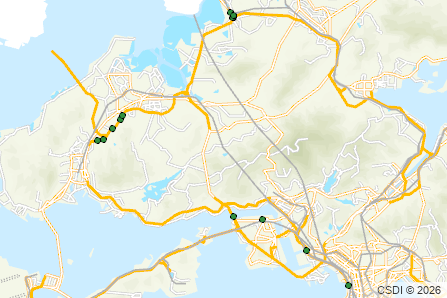

geom: esriGeometryPoint
count: 14
time: 1.234245s


status: 200
time: 1.056602s


status: 200
time: 0.994886s


Roadworks_Location_Data_FGDB.zip
size : 12702 bytes
time: 0.793671s


Roadworks_Location_Data_GEOPACKAGE.zip
size : 7934 bytes
time: 0.725346s


...

Timestamp('2026-08-07 20:52:11.894000')

'2022-03'

'2026-08'

'2026-08-07'

'2022-03'

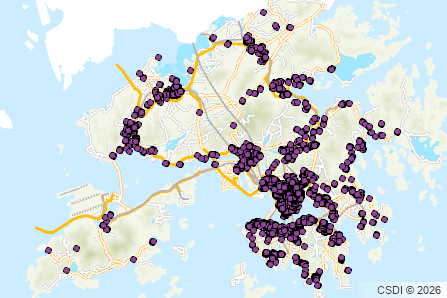

geom: esriGeometryPoint
count: 20671
time: 1.000744s


status: 200
time: 0.373924s


status: 200
time: 1.002747s


Distribution_of_Metered_Parking_Spaces_and_it_FGDB.zip
size : 512397 bytes
time: 0.704929s


Distribution_of_Metered_Parking_Spaces_and_it_GEOPACKAGE.zip
size : 1195638 bytes
time: 0.703576s


...

Timestamp('2026-08-07 20:47:04.310000')

'2026-08-07'

'2026-08-07'

'2026-08-07'

'2026-08-07'

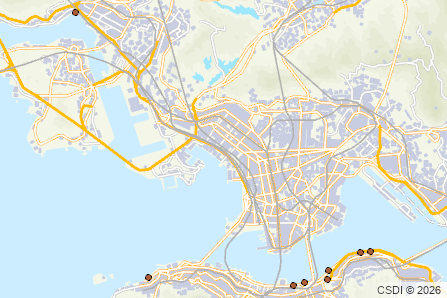

geom: esriGeometryPoint
count: 8
time: 0.932992s


status: 200
time: 1.033054s


status: 200
time: 0.931476s


Harbourfront_Shared_Space_GML.zip
size : 4364 bytes
time: 0.744309s


Harbourfront_Shared_Space_GEOPACKAGE.zip
size : 8172 bytes
time: 0.748581s


...

Timestamp('2026-08-07 20:43:13.716000')

'2026-02-25'

'2026-08-07'

'2026-08-07'

'2026-05-19'

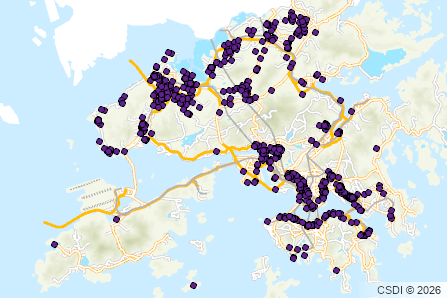

geom: esriGeometryPoint
count: 768
time: 1.029592s


status: 200
time: 1.04195s


status: 200
time: 0.997259s


Hong_Kong_Collector_Recycler_Directory_GML.zip
size : 109231 bytes
time: 0.711978s


Hong_Kong_Collector_Recycler_Directory_GEOPACKAGE.zip
size : 137725 bytes
time: 0.721815s


...

Timestamp('2026-08-07 20:38:57.446000')

'2021-06-01'

'2026-08-07'

'2026-08-07'

'2026-02-02'

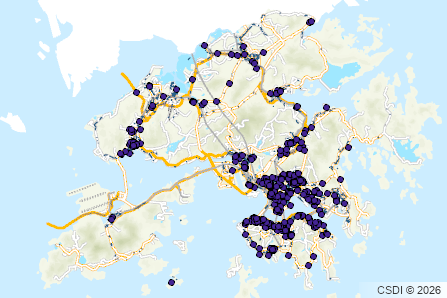

geom: esriGeometryPoint
count: 551
time: 0.939694s


geom: esriGeometryPolyline
count: 8139
time: 0.965377s


geom: esriGeometryPolygon
count: 12352
time: 0.967214s


status: 200
time: 1.001667s


status: 200
time: 0.945314s


...

Timestamp('2026-08-07 20:33:06.064000')

'2023-04'

'2026-08-07'

'2026-08-07'

'2023-04'

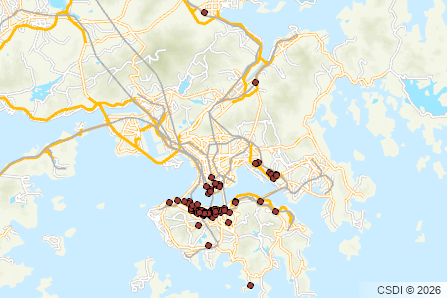

geom: esriGeometryPoint
count: 119
time: 0.9345s


status: 200
time: 2.380125s


status: 200
time: 1.016188s


List_of_Consulates_General_Honorary_Consulate_GML.zip
size : 19969 bytes
time: 0.739484s


List_of_Consulates_General_Honorary_Consulate_GEOPACKAGE.zip
size : 25436 bytes
time: 0.722833s


...

Timestamp('2026-08-07 20:28:52.301000')

'2022-02-18'

'2026-08-07'

'2026-08-07'

'2022-12-13'

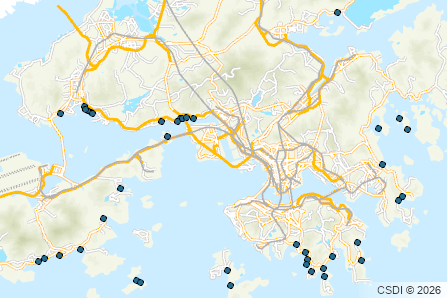

geom: esriGeometryPoint
count: 40
time: 0.945286s


status: 200
time: 1.031821s


status: 200
time: 0.304012s


Beach_Water_Quality_Grading_GML.zip
size : 2624 bytes
time: 0.737406s


Beach_Water_Quality_Grading_GEOPACKAGE.zip
size : 8231 bytes
time: 0.734684s


...

Timestamp('2026-08-07 20:24:37.835000')

'2023-06'

'2026-08-07'

'2026-08-07'

'2023'

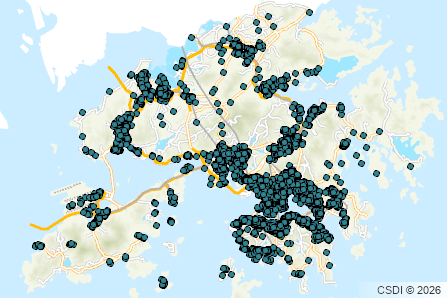

geom: esriGeometryPoint
count: 16445
time: 2.030642s


status: 200
time: 1.013751s


status: 200
time: 0.963631s


Food_licences_except_restaurant_licences_GML.zip
size : 3135283 bytes
time: 0.74249s


Food_licences_except_restaurant_licences_GEOPACKAGE.zip
size : 3015060 bytes
time: 0.721349s


...

Timestamp('2026-08-07 20:19:56.051000')

'2023-06'

'2026-08-07'

'2026-08-07'

'2023'

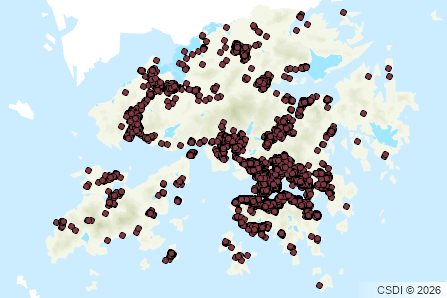

geom: esriGeometryPoint
count: 17140
time: 0.923108s


status: 200
time: 1.036694s


status: 200
time: 0.939378s


Restaurant_licences_GML.zip
size : 3223014 bytes
time: 0.722879s


Restaurant_licences_GEOPACKAGE.zip
size : 3133953 bytes
time: 0.736467s


...

Timestamp('2026-08-07 20:14:36.445000')

'2023-06'

'2026-08-07'

'2026-08-07'

'2023'

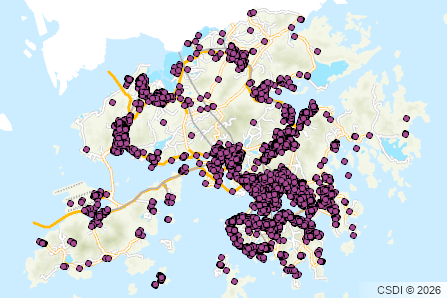

geom: esriGeometryPoint
count: 9825
time: 0.998825s


status: 200
time: 1.055202s


status: 200
time: 1.008963s


Sale_of_restricted_food_permits_GML.zip
size : 1632993 bytes
time: 0.814522s


Sale_of_restricted_food_permits_GEOPACKAGE.zip
size : 1491594 bytes
time: 0.709006s


...

Timestamp('2026-08-07 20:09:40.171000')

'2023-06'

'2026-08-07'

'2026-08-07'

'2023'

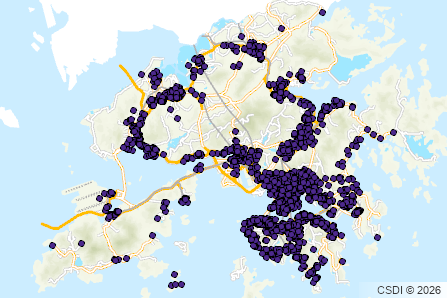

geom: esriGeometryPoint
count: 2030
time: 0.999996s


status: 200
time: 1.040856s


status: 200
time: 0.99786s


Trade_licences_for_places_of_public_entertain_GML.zip
size : 351683 bytes
time: 0.719268s


Trade_licences_for_places_of_public_entertain_GEOPACKAGE.zip
size : 352609 bytes
time: 1.121721s


...

Timestamp('2026-08-07 20:05:19.725000')

'2024-06-11'

'2026-08-07'

'2026-08-07'

'2024-06'

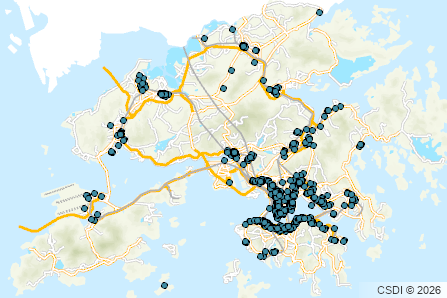

geom: esriGeometryPoint
count: 1061
time: 1.001379s


status: 200
time: 0.380149s


status: 200
time: 1.000973s


List_of_Licensed_Money_Service_Operators_GML.zip
size : 78931 bytes
time: 0.762088s


List_of_Licensed_Money_Service_Operators_GEOPACKAGE.zip
size : 117506 bytes
time: 0.761388s


...

List_of_Licensed_Money_Service_Operators_CSV.zip
size : 56739 bytes
time: 0.711225s


gen_sds_65fc4582289d11efa00d0050568fd79d.html
size : 10036 bytes
time: 0.703128s


gen_sds_65fc4582289d11efa00d0050568fd79d.xml
size : 12885 bytes
time: 0.716482s


sds.json
size : 7033 bytes
time: 0.698534s


MSO_Licensee_Register_List_GML_geotagging_converted.geojson
size : 728269 bytes
time: 1.131932s


In [ ]:
## dataset detail ##
#df1=df.sample(n=1).copy().reset_index()
checkdat(df,0,11)

In [ ]:
## read metadata ##
for index,data in df.loc[0:1].iterrows():
  #if index > 1:
    #break
  print('-----')
  id=data['id']
  title=data['title']
  display(HTML(f'<b>{index}/{len(df)} {id}</b>'))
  #display(f'index: {index}')
  display(HTML(f'<a href="https://portal.csdi.gov.hk/geoportal/?lang=en&datasetId={id}">{title}</a>'))
  display(data['updated'])
  #print(pd.to_datetime(data['updated'],format='%Y-%m-%dT%H:%M:%S.%fZ')+td(hours=8))
  #getlink(data['_source.links_s'])
  readxml(data['_source.sys_xml_clob'])

-----


Timestamp('2026-08-04 21:39:59.643000')

Thesaurus: Class of spatial data in CSDI, version 1.0
Common Sharable Spatial Data (CSSD)
Thesaurus: CSDI data category, version 1.0
***Title***
Refreshment Kiosk in Country Parks
郊野公園的小食亭
郊野公园的小食亭
***Theme***
Common Sharable Spatial Data (CSSD)
-
-
***FSDT***
-
-
-
***Category***
[{'cat_en': 'Common Sharable Spatial Data (CSSD)', 'cat_zh': '-', 'cat_cn': '-'}, {'cat_en': 'Common Sharable Spatial Data (CSSD)', 'cat_zh': '-', 'cat_cn': '-'}]
***Keyword***
***Abstract***
Location information of Refreshment Kiosk in Country Parks
郊野公園的小食亭位置資料
郊野公园的小食亭位置资料
***Date***
metadata Date: 2025-05-21
Creation Date: 2023-05-31
Revision Date: 2026-08-04
Publication Date: 2026-08-04
***Update Frequency***
Freq Code: asNeeded
As and when there is update
當有更新數據時
当有更新数据时
***Organization***
Agriculture, Fisheries and Conservation Department
漁農自然護理署
渔农自然护理署
***Contact***
Country Parks Ranger Services Officer (Special Projects)
郊野公園護理主任 (特別項目)
郊野公园护理主任 (特别项目)
***Phone***
21506883
***fax***
-
***email***
ma

/tmp/ipykernel_788/2595163840.py:438: DeprecationWarning: Testing an element's truth value will always return True in future versions.  Use specific 'len(elem)' or 'elem is not None' test instead.
  elif root.find('gmd:identificationInfo',ns).find('gmd:MD_DataIdentification',ns).find('gmd:pointOfContact',ns).find('gmd:CI_ResponsibleParty',ns).find('gmd:contactInfo',ns):
/tmp/ipykernel_788/2595163840.py:443: DeprecationWarning: Testing an element's truth value will always return True in future versions.  Use specific 'len(elem)' or 'elem is not None' test instead.
  if ci_contact.find('gmd:phone',ns):
/tmp/ipykernel_788/2595163840.py:445: DeprecationWarning: Testing an element's truth value will always return True in future versions.  Use specific 'len(elem)' or 'elem is not None' test instead.
  if ci_phone.find('gmd:voice',ns):
/tmp/ipykernel_788/2595163840.py:449: DeprecationWarning: Testing an element's truth value will always return True in future versions.  Use specific 'len(elem)

Timestamp('2026-08-04 21:35:16.254000')

Thesaurus: Class of spatial data in CSDI, version 1.0
Common Sharable Spatial Data (CSSD)
Thesaurus: CSDI data category, version 1.0
***Title***
Roadworks Location Data
道路工程位置數據
道路工程位置数据
***Theme***
Common Sharable Spatial Data (CSSD)
-
-
***FSDT***
-
-
-
***Category***
[{'cat_en': 'Common Sharable Spatial Data (CSSD)', 'cat_zh': '-', 'cat_cn': '-'}]
***Keyword***
***Abstract***
Location of roadworks by Highways Department for roads with speed limit ≥ 70km/h
位於時速限制 70 公里或以上的路政署道路工程位置
位于时速限制 70 公里或以上的路政署道路工程位置
***Date***
metadata Date: 2026-06
Creation Date: 2026-06
Revision Date: 2026-08
Publication Date: 2026-08-04
***Update Frequency***
Freq Code: unknown
As and when necessary
有需要時
有需要时
***Organization***
Transport Department
運輸署
运输署
***Contact***
TD General Enquiry Hotline
運輸署一般查詢熱線
运输署一般查询热线
***Phone***
-
***fax***
-
***email***
tdenq@td.gov.hk


In [ ]:
### read opensearch and generate html ###
def df_export_html(df):
  styled_df=df.style.set_table_styles([{"selector": "tbody tr:nth-child(even)","props": [("background-color", "#f2f2f2"),("text-align","center")]},{"selector": "tbody tr:nth-child(odd)","props": [("background-color", "white"),("text-align","center")]}]).set_uuid('myTable')
  html_table = styled_df.to_html(classes="display")
  html_page = f'''
  <!DOCTYPE html>
  <html>
  <head>
    <meta charset="UTF-8">
    <title>CSDI {site} Portal</title>
    <!-- DataTables CSS -->
    <link rel="stylesheet"
          href="https://cdn.datatables.net/1.13.6/css/jquery.dataTables.min.css">
    <style>
        table.dataTable thead th {{
            "cursor": pointer;
            "background-color": #d3d3d3;
            "color": black;
            "text-align": center;
        }}
        table.dataTable tbody td {{
            "text-align": center;
        }}
    </style>
  </head>
  <body>
    <h2>CSDI {site} Portal Dataset List</h2>
    {html_table}

    <!-- jQuery -->
    <script src="https://code.jquery.com/jquery-3.7.0.min.js"></script>
    <!-- DataTables JS -->
    <script src="https://cdn.datatables.net/1.13.6/js/jquery.dataTables.min.js"></script>
    <script>
        $(document).ready(function() {{
            $("#T_myTable").DataTable({{
                "paging": true,   // Disable pagination
                "info": false,
                "ordering": true,
                "ordee": [[0,'asc']]      // Hide "Showing X of Y entries"
            }});
        }});
    </script>
  </body>
  </html>
  '''
  out_path=os.path.join(html_path,file_name)
  with open(out_path, "w", encoding="utf-8") as f:
    f.write(html_page)

site='Primary'
#site='Secondary'
spath='/content/drive/MyDrive/CSDI/csv/srctype.csv'
dfs=pd.read_csv(spath)
#print(dfsource)
df=readjson(site)
linkres=[]
for index,data in df.iterrows():
  id=data['id']
  title=data['title']
  theme=data['_source.themes_s'][0]
  #print(theme)
  if 'CSSD' in theme:
    theme='CSSD'
  else:
    theme='FSDT'
  #print(id, title)
  try:
    srcform=dfs.loc[dfs['id']==id,'type'].iat[0]
  except:
    srcform='-'
  xmltext=data['_source.sys_xml_clob']
  df.at[index,'title']=f'<a href="https://portal.csdi.gov.hk/geoportal/?lang=en&datasetId={id}">{title}</a>'
  df.at[index,'source']=srcform
  df.at[index,'preview']=f'<a href="{data['_source.url_thumbnail_s']}">Preview</a>'
  df.at[index,'theme']=theme
  getxmllink(xmltext,index,False)
pd.set_option('display.max_colwidth',30)
#df.keys()
dflink=pd.DataFrame(linkres)
#srclist=['FGDB','GML','GEOPACKAGE','SHP','GEOTIFF']
#dflink2=dflink[dflink['type'].isin(srclist)].drop_duplicates('id')
path=f'/content/drive/MyDrive/CSDI/csv/{site}_link.csv'
dflink.to_csv(path,index=False)
html_path='/content/drive/MyDrive/CSDI/html'
file_name=f'{site}.html'
df_html=df[['author.name','title','theme','metadata_date','creation_date','revision_date','publication_date','freq','preview','ARCGIS','WFS','WMS','source','FGDB','GML','SHP','GEOPACKAGE','GEOJSON','KML','CSV','GEOTIFF','FILE_API_GEOJSON','ARCHIVE_DATASET']]
df_export_html(df_html)
display(HTML(df_html.head(40).to_html(escape=False)))

,author.name,title,theme,metadata_date,creation_date,revision_date,publication_date,freq,preview,ARCGIS,WFS,WMS,source,FGDB,GML,SHP,GEOPACKAGE,GEOJSON,KML,CSV,GEOTIFF,FILE_API_GEOJSON,ARCHIVE_DATASET
0,Transport Department,Roadworks Location Data,CSSD,2026-06-01,2026-06-01,2026-08-01,2026-08-07,As and when necessary,Preview,Y,Y,Y,FGDB,Y,Y,NaN,Y,Y,Y,Y,NaN,Y,Y
1,Transport Department,Distribution of Metered Parking Spaces and its Occupancy,CSSD,2022-03-01,2022-03-01,2026-08-01,2026-08-07,Real-time,Preview,Y,Y,Y,FGDB,Y,Y,NaN,Y,Y,Y,Y,NaN,Y,Y
2,Development Bureau,Harbourfront Shared Space,CSSD,2026-08-07,2026-08-07,2026-08-07,2026-08-07,As and when there is update,Preview,Y,Y,Y,GML,Y,Y,NaN,Y,Y,Y,Y,NaN,Y,Y
3,Environmental Protection Department,Hong Kong Collector / Recycler Directory,CSSD,2026-05-19,2026-02-25,2026-08-07,2026-08-07,Twice per Year,Preview,Y,Y,Y,GML,Y,Y,Y,Y,Y,Y,Y,NaN,Y,Y
4,Highways Department,Excavation Permit,CSSD,2026-02-02,2021-06-01,2026-08-07,2026-08-07,Weekly,Preview,Y,Y,Y,FGDB,Y,Y,Y,Y,Y,Y,NaN,NaN,Y,Y
5,"Administration Wing, Chief Secretary for Administration's Office","List of Consulates-General, Honorary Consulates and Officially Recognised Bodies in Hong Kong",CSSD,2023-04-01,2023-04-01,2026-08-07,2026-08-07,As and when there is update,Preview,Y,Y,Y,GML,Y,Y,Y,Y,Y,Y,Y,NaN,Y,Y
6,Environmental Protection Department,Beach Water Quality Grading,CSSD,2022-12-13,2022-02-18,2026-08-07,2026-08-07,As and when there is update,Preview,Y,Y,Y,GML,Y,Y,Y,Y,Y,Y,Y,NaN,Y,Y
7,Food and Environmental Hygiene Department,Food licences (except restaurant licences),CSSD,2023-01-01,2023-06-01,2026-08-07,2026-08-07,Daily,Preview,Y,Y,Y,GML,Y,Y,NaN,Y,Y,Y,Y,NaN,Y,Y
8,Food and Environmental Hygiene Department,Restaurant licences,CSSD,2023-01-01,2023-06-01,2026-08-07,2026-08-07,Daily,Preview,Y,Y,Y,GML,Y,Y,NaN,Y,Y,Y,Y,NaN,Y,Y
9,Food and Environmental Hygiene Department,Sale of restricted food permits,CSSD,2023-01-01,2023-06-01,2026-08-07,2026-08-07,Daily,Preview,Y,Y,Y,GML,Y,Y,Y,Y,Y,Y,Y,NaN,Y,Y


In [ ]:
df.keys()
#df['_source.apiso_PublicationDate_dt']
#df['create_date']=df['_source.apiso_CreationDate_dt'].apply(lambda x:x[0:10])
#df['rev_date']=df['_source.apiso_RevisionDate_dt'].apply(lambda x:x[0:10])
#df['pub_date']=df['_source.apiso_PublicationDate_dt'].apply(lambda x:str(x)[0:10])
#df['pub_date']
#display(HTML(df[['author.name','title','_source.sys_xmlmeta_obj.date','create_date','rev_date','pub_date','preview','ARCGIS','WFS','WMS','FGDB','GML','SHP','GEOPACKAGE','GEOJSON','KML','CSV','GEOTIFF','FILE_API_GEOJSON','ARCHIVE_DATASET']].to_html(escape=False)))
#df[['author.name','title','_source.sys_xmlmeta_obj.date','create_date','rev_date','pub_date','preview','ARCGIS','WFS','WMS','FGDB','GML','SHP','GEOPACKAGE','GEOJSON','KML','CSV','GEOTIFF','FILE_API_GEOJSON','ARCHIVE_DATASET']].to_html(out_path,escape=False)

Index(['id', 'title', 'description', 'published', 'updated', 'links',
       'author.name', 'bbox.xmin', 'bbox.ymin', 'bbox.xmax', 'bbox.ymax',
       '_source.sys_created_dt', '_source.sys_modified_dt',
       '_source.sys_xmlmodified_dt', '_source.sys_access_s',
       '_source.sys_owner_s', '_source.sys_owner_txt',
       '_source.sys_metadatatype_s', '_source.sys_xml_clob',
       '_source.sys_xmlmeta_obj.mimetype', '_source.sys_xmlmeta_obj.hash',
       '_source.sys_xmlmeta_obj.date', '_source.sys_xmlmeta_obj.size',
       '_source.sys_access_groups_s', '_source.fileid', '_source.title',
       '_source.description', '_source.thumbnail_s',
       '_source.contact_organizations_s', '_source.contact_people_s',
       '_source.csw_creator_s', '_source.links_s',
       '_source.apiso_Identifier_s', '_source.apiso_Title_txt',
       '_source.apiso_Abstract_txt', '_source.apiso_BrowseGraphic_s',
       '_source.apiso_OrganizationName_txt', '_source.themes_s',
       '_source.categories_

In [ ]:
#df.keys()
def getlinks(links):
  list=[]
  for link in df['links']:
    for a in link:
      row=a
      list.append(a)
  dflink=pd.DataFrame(list)
  return dflink
#df.info()

def changeopensearchtype(df):
  for a in df.keys():
    #print(a)
    pats=['_dt','published','date']
    if any(pat in a for pat in pats):
      #print(a)
      try:
        df[a]=df[a].apply(lambda x:dt.strptime(x,'%Y-%m-%dT%H:%M:%S.%fZ' if len(x)==24 else '%Y-%m-%dT%H:%M:%SZ'))+td(hours=8)
      except:
        continue
    elif a.endswith('_s') or a=='author.name':
      #print(a)
      try:
        df[a].astype('category')
      except:
        continue
  df=df.convert_dtypes()
  return df

df=changeopensearchtype(df)
df.info()
#dfexp=df[['id','_source.links_s']].explode('_source.links_s')
#len(dfexp)
#dfexp[dfexp['_source.links_s'].str.contains('portal.csdi')]
#len(dfexp)
#dflink=pd.json_normalize(dfexp['links'])
#dflink
#dflink=getlinks(df['links'])
#dflink[dflink['dctype'].notna()]
#df['_source.apiso_CreationDate_dt']=pd.to_datetime(df['_source.apiso_CreationDate_dt'])
#df['_source.apiso_RevisionDate_dt']=pd.to_datetime(df['_source.apiso_RevisionDate_dt'])
#df[['id','author.name','title','updated','_source.apiso_RevisionDate_dt']].sort_values('_source.apiso_RevisionDate_dt',ascending=False)
#df.groupby(['author.name','title','_source.themes_s',pd.Grouper(key='_source.apiso_RevisionDate_dt',freq='1M')])['id'].count()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 71 columns):
 #   Column                                             Non-Null Count  Dtype         
---  ------                                             --------------  -----         
 0   id                                                 1143 non-null   string        
 1   title                                              1143 non-null   string        
 2   description                                        1143 non-null   string        
 3   published                                          1143 non-null   datetime64[ns]
 4   updated                                            1143 non-null   datetime64[ns]
 5   links                                              1143 non-null   object        
 6   categories                                         664 non-null    object        
 7   author.name                                        1143 non-null   string        
 8   bbox.xmin         